# Initial notebook 

In [6]:
import pyopencl as cl

# List all platforms
platforms = cl.get_platforms()

for i, platform in enumerate(platforms):
    print(f"\nPlatform {i}: {platform.name} ({platform.vendor})")
    
    devices = platform.get_devices()
    for j, device in enumerate(devices):
        print(f"  Device {j}: {device.name}")
        print(f"    Type      : {cl.device_type.to_string(device.type)}")
        print(f"    Max Compute Units: {device.max_compute_units}")
        print(f"    Global Memory    : {device.global_mem_size // (1024**2)} MB")
        print(f"    Max Work Group Size: {device.max_work_group_size}")



Platform 0: Apple (Apple)
  Device 0: Apple M1
    Type      : ALL | GPU
    Max Compute Units: 8
    Global Memory    : 5461 MB
    Max Work Group Size: 256


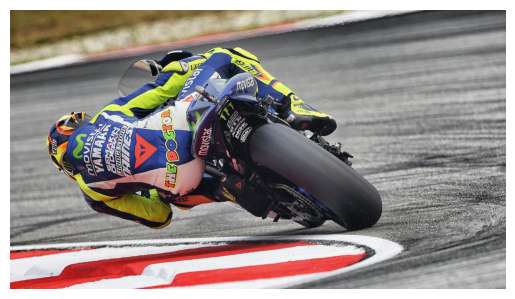

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pyopencl as cl
from PIL import Image
import os
os.environ["PYOPENCL_COMPILER_OUTPUT"] = "1"


# === 1. Load RGBA image ===
img = Image.open("/Users/satheeshdm/Desktop/MTech/Semester-3/Project/zerocoin_application/zerocoin_exercise/data/sample.png")
if img.mode != 'RGBA':
    img = img.convert("RGBA")
img_np = np.array(img, dtype=np.uint8)

plt.imshow(img_np)
plt.axis('off')  # Hide axes
plt.show()


In [8]:
# === 2. Set up OpenCL context ===
platform = cl.get_platforms()[0]
device = platform.get_devices()[0]
ctx = cl.Context([device])
queue = cl.CommandQueue(ctx)

# === 3. Define OpenCL image format ===
image_format = cl.ImageFormat(cl.channel_order.RGBA, cl.channel_type.UNORM_INT8)

# === 4. Upload input image to GPU ===
input_image = cl.Image(
    ctx,
    cl.mem_flags.READ_ONLY | cl.mem_flags.COPY_HOST_PTR,
    format=image_format,
    shape=(img_np.shape[1], img_np.shape[0]),  # (width, height)
    hostbuf=img_np
)

# === 5. Create GPU images for intermediate and final output ===
blurred_image = cl.Image(
    ctx,
    cl.mem_flags.READ_WRITE,
    format=image_format,
    shape=(img_np.shape[1], img_np.shape[0])
)

final_image = cl.Image(
    ctx,
    cl.mem_flags.WRITE_ONLY,
    format=image_format,
    shape=(img_np.shape[1], img_np.shape[0])
)

# === 6. Load and build OpenCL program ===
try:
    program = cl.Program(ctx, open("gaussian_blur_and_tone_mapping.cl").read()).build()
    print("Kernels found in program:", program.get_info(cl.program_info.KERNEL_NAMES))

except Exception as e:
    print("Build log:\n", program.get_build_info(device, cl.program_build_info.LOG))
    raise e

Kernels found in program: gaussian_blur;tone_map_logarithmic


/var/folders/2x/n83t3hnj2754fpn_pyp160m00000gn/T/ipykernel_50232/3541797124.py:11: DeprecationWarning: Non-descriptor Image constructor called. This will stop working in 2026. Use create_image instead (with the same arguments).
  input_image = cl.Image(
/var/folders/2x/n83t3hnj2754fpn_pyp160m00000gn/T/ipykernel_50232/3541797124.py:20: DeprecationWarning: Non-descriptor Image constructor called. This will stop working in 2026. Use create_image instead (with the same arguments).
  blurred_image = cl.Image(
/var/folders/2x/n83t3hnj2754fpn_pyp160m00000gn/T/ipykernel_50232/3541797124.py:27: DeprecationWarning: Non-descriptor Image constructor called. This will stop working in 2026. Use create_image instead (with the same arguments).
  final_image = cl.Image(


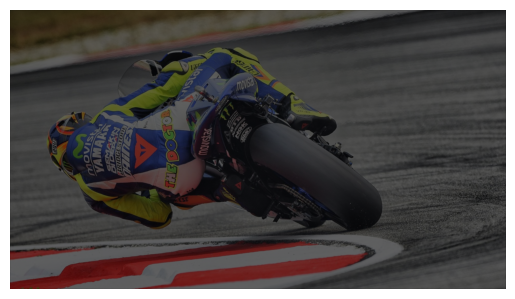

In [9]:
# === 7. Run Gaussian blur kernel ===
global_size = (img_np.shape[1], img_np.shape[0])  # (width, height)
program.gaussian_blur(queue, global_size, None, input_image, blurred_image)

# === 8. Run tone mapping kernel ===
max_luminance = np.float32(5.0)
program.tone_map_logarithmic(queue, global_size, None, blurred_image, final_image, max_luminance)

# === 9. Download final image back to CPU ===
result_np = np.empty_like(img_np)
origin = (0, 0, 0)
region = (img_np.shape[1], img_np.shape[0], 1)  # (width, height, depth)
cl.enqueue_copy(queue, result_np, final_image, origin=origin, region=region)

# === 10. Show or save the result ===
Image.fromarray(result_np, 'RGBA').save("/Users/satheeshdm/Desktop/MTech/Semester-3/Project/zerocoin_application/zerocoin_exercise/data/output_processed.png")
plt.imshow(result_np)
plt.axis('off')
plt.show()